# Результаты

В ходе обучения нейронный мной были опробованы различные параметры.

Модели без dropout и batch нормализации:
- Однослойная нейросеть плохо справляется с описанием сложной функции. Успехов удалось добиться на большом количестве нейронов и количестве эпох обучения >1000.
- Двухслойная нейросеть с большим количеством эпох обучения относительно хорошо справилась с предсказанием, однако предсказывает сильно меньший диапазон значений и сводит их ближе к 0.
- Трехслойная модель сводит все значения к 0. Предсказания 0 на всех входных данных дает достаточно малую ошибку, чтобы признать такое решение оптимальным.

Модели с dropout и batch нормализацией:
- Двухслойная модель хорошо описывает примерное распределение. Пики значений неравномерные, но суть улавливается.
- Трехслойная модель еще лучше описывает распределение. Пики значений все еще неравномерные, но они гораздо ближе к истине.

Итоги:
- Простой метод обучения "в лоб" может подойти относительно простым датасетам.
- Для сложных датасетов необходимо применять методы борьбы с переобучением, особенно если в датасете много одинаковых данных (как например в данном сете много нулей).
- Кросс-валидация параметров очень затратный процесс. Кросс-валидация трех слоев нейросети без dropout и batch нормализации заняла 70 часов на GPU.
- В ходе изучения подбора параметров было обнаружено и изучено, что не существует золотого правила подбора параметров. Нужно опираться на свой опыт и некоторые эвристики.

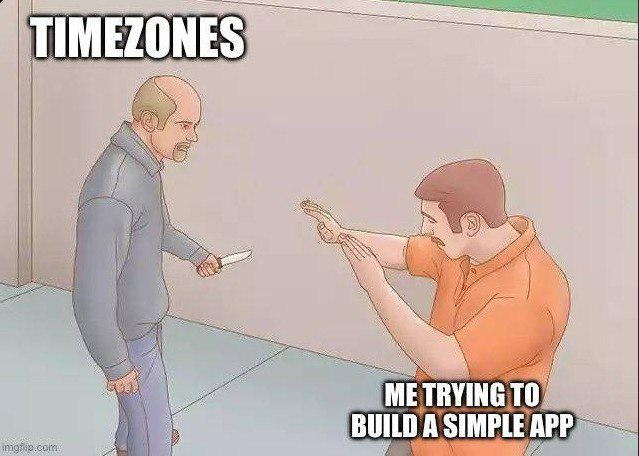

All data loss: 0.0010


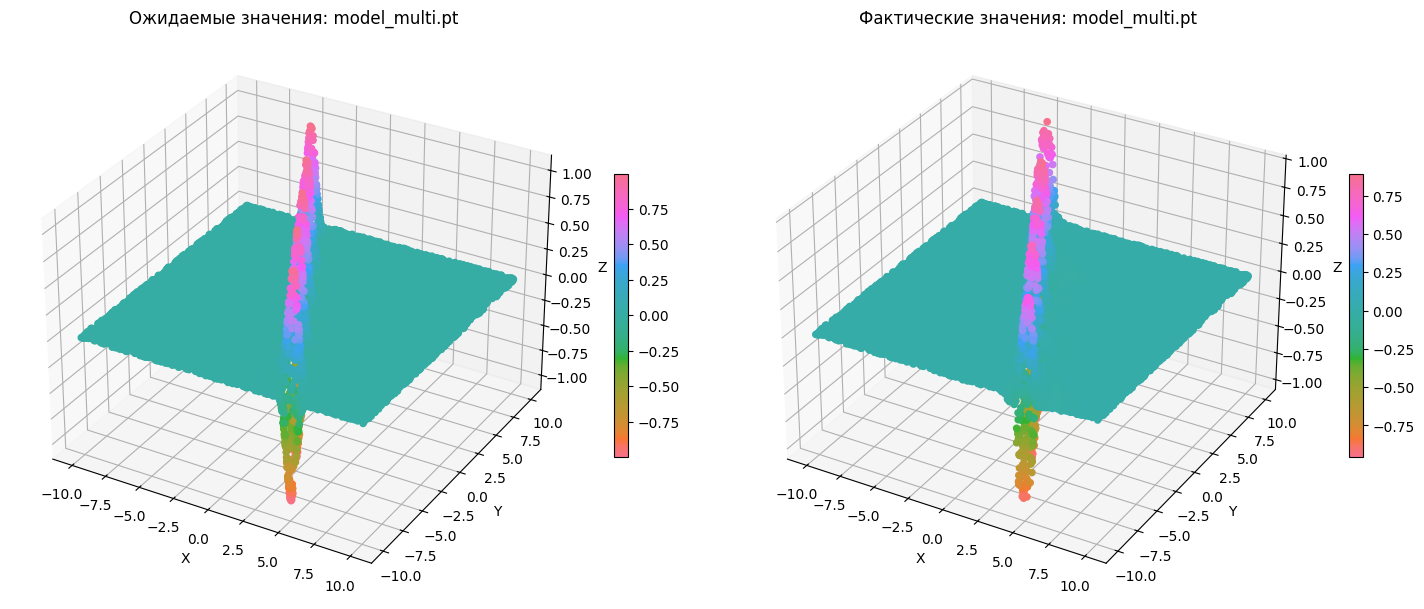

In [1]:
from pathlib import Path

import torch
from torch import nn

from plt_utils import visualize
from regression_model import build_model_and_optimizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

target = torch.load('target.pt')

folder = Path("./")
for file in folder.glob('model_*.pt'):
    metadata = torch.load(file, weights_only=False)
    model = build_model_and_optimizer(metadata["params"], skip_optimizer=True)

    model.load_state_dict(metadata['model_state_dict'])

    model.to(device)
    model.eval()

    criterion = nn.MSELoss()

    all_outputs = model(target[:, :-1].to(device))
    loss = criterion(all_outputs, target[:, -1].reshape(-1, 1).to(device))

    print('All data loss: {:.4f}'.format(loss.item()))

    visualize(target, all_outputs, file)